In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.random.rand(100, 3)
X[:, 0] *= 200   # Inlet temperature
X[:, 1] *= 50    # Feed rate
X[:, 2] *= 30000 # Atomization speed

y = 0.3*X[:,0] - 0.02*X[:,1] + 0.0001*X[:,2] + np.random.randn(100)*5

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)


def fitness_function(hidden_neurons):
    model = MLPRegressor(
        hidden_layer_sizes=(hidden_neurons,),
        max_iter=500,
        random_state=1
    )

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)

    return 1 / (1 + mse)


def selection(population, fitness_scores):
    selected = []
    pop_size = len(population)

    for _ in range(pop_size):
        i = random.randint(0, pop_size - 1)
        j = random.randint(0, pop_size - 1)

        selected.append(
            population[i] if fitness_scores[i] > fitness_scores[j] else population[j]
        )

    return selected


def crossover(parents, crossover_rate):
    offspring = []

    for i in range(0, len(parents), 2):
        if i + 1 < len(parents) and random.random() < crossover_rate:
            child = (parents[i] + parents[i + 1]) // 2
        else:
            child = parents[i]

        offspring.append(child)

    return offspring


def mutation(offspring, mutation_rate):
    for i in range(len(offspring)):
        if random.random() < mutation_rate:
            offspring[i] += random.randint(-2, 2)
            offspring[i] = max(1, offspring[i])

    return offspring


population_size = 10
generations = 20
crossover_rate = 0.85
mutation_rate = 0.05

population = [random.randint(5, 20) for _ in range(population_size)]

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

best_fitness_history = []
best_solution = None
best_fitness = 0


for gen in range(generations):

    fitness_scores = [fitness_function(ind) for ind in population]

    current_best = max(fitness_scores)
    current_solution = population[fitness_scores.index(current_best)]

    best_fitness_history.append(current_best)

    if current_best > best_fitness:
        best_fitness = current_best
        best_solution = current_solution

    print(
        f"Generation {gen+1}: Best Neurons = {current_solution}, Fitness = {current_best:.4f}"
    )

    selected = selection(population, fitness_scores)
    offspring = crossover(selected, crossover_rate)
    population = mutation(offspring, mutation_rate)




Generation 1: Best Neurons = 7, Fitness = 0.0016
Generation 2: Best Neurons = 13, Fitness = 0.0063
Generation 3: Best Neurons = 7, Fitness = 0.0016
Generation 4: Best Neurons = 7, Fitness = 0.0016
Generation 5: Best Neurons = 7, Fitness = 0.0016
Generation 6: Best Neurons = 7, Fitness = 0.0016
Generation 7: Best Neurons = 7, Fitness = 0.0016
Generation 8: Best Neurons = 7, Fitness = 0.0016
Generation 9: Best Neurons = 7, Fitness = 0.0016
Generation 10: Best Neurons = 7, Fitness = 0.0016
Generation 11: Best Neurons = 7, Fitness = 0.0016
Generation 12: Best Neurons = 7, Fitness = 0.0016
Generation 13: Best Neurons = 7, Fitness = 0.0016
Generation 14: Best Neurons = 7, Fitness = 0.0016
Generation 15: Best Neurons = 7, Fitness = 0.0016
Generation 16: Best Neurons = 7, Fitness = 0.0016
Generation 17: Best Neurons = 7, Fitness = 0.0016
Generation 18: Best Neurons = 7, Fitness = 0.0016
Generation 19: Best Neurons = 7, Fitness = 0.0016
Generation 20: Best Neurons = 7, Fitness = 0.0016


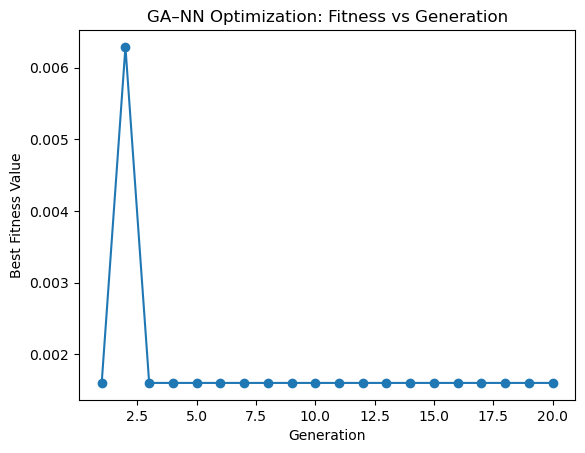

In [5]:
# Plot
plt.figure()
plt.plot(range(1, generations + 1), best_fitness_history, marker='o')
plt.xlabel("Generation")
plt.ylabel("Best Fitness Value")
plt.title("GA–NN Optimization: Fitness vs Generation")
plt.show()




In [6]:
print("\nFinal Optimized Result")
print("Optimal Hidden Neurons:", best_solution)
print("Best Fitness Value:", round(best_fitness, 4))


Final Optimized Result
Optimal Hidden Neurons: 13
Best Fitness Value: 0.0063
